In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"

  # IPython 7.14 deprecated set_matplotlib_formats from IPython
  try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
  except ImportError:
    # Fall back to deprecated location for older IPython versions
    from IPython.display import set_matplotlib_formats
    
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'QzpcVXNlcnNcZmFiaW9cRG9jdW1lbnRzXERhdGFfQW5hbHlzaXNfUHJvamVjdHNcbXktYW5hbHl0aWNzLWJsb2dccG9zdHNcZGF0YS1jbGVhbmluZy1wcm9qZWN0X3BhcnQtMg=='
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"C:\\Python311\\Lib\\importlib\\_bootstrap.py": 1675785262.0, "C:\\Python311\\Lib\\importlib\\_bootstrap_external.py": 1675785262.0, "C:\\Python311\\Lib\\zipimport.py": 1675785262.0, "C:\\Python311\\Lib\\codecs.py": 1675785262.0, "C:\\Python311\\Lib\\encodings\\aliases.py": 1675785262.0, "C:\\Python311\\Lib\\encodings\\__init__.py": 1675785262.0, "C:\\Python311\\Lib\\encodings\\utf_8.py": 1675785262.0, "C:\\Python311\\Lib\\encodings\\cp1252.py": 1675785262.0, "C:\\Python311\\Lib\\abc.py": 1675785262.0, "C:\\Python311\\Lib\\io.py": 1675785262.0, "C:\\Python311\\Lib\\stat.py": 1675785262.0, "C:\\Python311\\Lib\\_collections_abc.py": 1675785262.0, "C:\\Python311\\Lib\\genericpath.py": 1675785262.0, "C:\\Python311\\Lib\\ntpath.py": 1675785262.0, "C:\\Python311\\Lib\\os.py": 1675785262.0, "C:\\Python311\\Lib\\_sitebuiltins.py": 1675785262.0, "C:\\Users\\fabio\\Documents\\Data_Analysis_Projects\\.venv\\Lib\\site-packages\\_distutils_hack\\__init__.py": 1789130179.1805081, "C:\\Python311\\Li

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Set global visual style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

# Load cleaned Parquet dataset
df = pd.read_parquet("../data_dcp/clean_online_retail.parquet")
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print(f"Dataset successfully loaded: {len(df):,} rows across {df['Country'].nunique()} countries.")

Dataset successfully loaded: 396,337 rows across 37 countries.


In [3]:
def basic_info():
    print(f"The dataset has {df.shape[0]} rows across {df.shape[1]} columns")

    col_names = list(df.columns)

    print(f"\nThe columns are:\n")
    for c in col_names:
        print(f"{c}")

    print(f"\nThe data types of the columns are below")
    print(df.dtypes)

# Call the function
basic_info()

The dataset has 396337 rows across 8 columns

The columns are:

InvoiceNo
StockCode
Description
Quantity
InvoiceDate
UnitPrice
CustomerID
Country

The data types of the columns are below
InvoiceNo                 str
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object


In [4]:
# Calculate the total revenue
df['TotalRevenue'] = df['UnitPrice']*df['Quantity']
Total_spend = df.groupby('CustomerID')['TotalRevenue'].sum().reset_index()

print("This is the Total spend by the customer")
print(Total_spend)

# Aggregate daily revenue
daily_revenue = (
    df.groupby(df['InvoiceDate'].dt.date)['TotalRevenue']
    .sum()
    .reset_index()
)
daily_revenue.columns = ['Date', 'Revenue']

# Display first few rows as a formatted table
print("This is a summary of the daily revenue")
print(daily_revenue.head())

This is the Total spend by the customer
      CustomerID  TotalRevenue
0        12346.0      77183.60
1        12347.0       4310.00
2        12348.0       1437.24
3        12349.0       1457.55
4        12350.0        294.40
...          ...           ...
4329     18280.0        180.60
4330     18281.0         80.82
4331     18282.0        178.05
4332     18283.0       2088.93
4333     18287.0       1837.28

[4334 rows x 2 columns]


This is a summary of the daily revenue
         Date   Revenue
0  2010-12-01  46219.29
1  2010-12-02  47283.53
2  2010-12-03  23576.01
3  2010-12-05  31315.64
4  2010-12-06  31014.21


In [5]:
# The datetime conversion shows the date and time of purchase.
# To use only the date, extract date only
df['InvoiceDay'] = df['InvoiceDate'].dt.date

# Find the most recent purchases by Customer ID
Recent_customer_purchase = df.groupby('CustomerID')['InvoiceDay'].max().reset_index()

print(Recent_customer_purchase)

# What's the most recent date in the dataset?
Most_recent_date = df['InvoiceDay'].max()
print(Most_recent_date)

      CustomerID  InvoiceDay
0        12346.0  2011-01-18
1        12347.0  2011-12-07
2        12348.0  2011-09-25
3        12349.0  2011-11-21
4        12350.0  2011-02-02
...          ...         ...
4329     18280.0  2011-03-07
4330     18281.0  2011-06-12
4331     18282.0  2011-12-02
4332     18283.0  2011-12-06
4333     18287.0  2011-10-28

[4334 rows x 2 columns]
2011-12-09


In [6]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)
print("One day after last purchase date:")
print(snapshot_date)

# Aggregate per customer
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,  # Recency
    "InvoiceNo": "nunique",                                  # Frequency (distinct orders)
    "TotalRevenue": "sum"                                      # Monetary value
}).reset_index()

# Rename columns
rfm.columns = ["CustomerID", "Recency", "Frequency", "Monetary"]

One day after last purchase date:
2011-12-10 12:50:00


In [7]:
rfm["R_Score"] = pd.qcut(rfm["Recency"], q=5, labels=[5, 4, 3, 2, 1])

# F: Higher frequency = higher score
# duplicates='drop' is useful if many customers have only 1 order
rfm["F_Score"] = pd.qcut(rfm["Frequency"].rank(method="first"), q=5, labels=[1, 2, 3, 4, 5])

# M: Higher spend = higher score
rfm["M_Score"] = pd.qcut(rfm["Monetary"], q=5, labels=[1, 2, 3, 4, 5])

# Combined RFM Score string (e.g., "555") and numeric sum
rfm["RFM_Cell"] = rfm["R_Score"].astype(str) + rfm["F_Score"].astype(str) + rfm["M_Score"].astype(str)
rfm["RFM_Score"] = rfm[["R_Score", "F_Score", "M_Score"]].astype(int).sum(axis=1)


# Map scores to customer segments
def segment_customer(row):
    r, f = int(row["R_Score"]), int(row["F_Score"])
    
    if r >= 4 and f >= 4:
        return "Champions"
    elif r >= 3 and f >= 3:
        return "Loyal Customers"
    elif r >= 4 and f == 1:
        return "New Customers"
    elif r == 3 and f == 1:
        return "Promising / Potential Loyalists"
    elif r <= 2 and f >= 3:
        return "At Risk / Need Attention"
    elif r == 1 and f >= 4:
        return "Can't Lose Them"
    elif r <= 2 and f <= 2:
        return "Hibernating / Lost"
    else:
        return "About to Sleep"

rfm["Customer_Segment"] = rfm.apply(segment_customer, axis=1)

segment_summary = rfm.groupby("Customer_Segment").agg(
    Recency_Mean=("Recency", "mean"),
    Frequency_Mean=("Frequency", "mean"),
    Monetary_Mean=("Monetary", "mean"),
    Customer_Count=("CustomerID", "count")
).round(2).sort_values(by="Monetary_Mean", ascending=False)

print(segment_summary)

                                 Recency_Mean  Frequency_Mean  Monetary_Mean  \
Customer_Segment                                                               
Champions                               13.27            9.94        5142.43   
Loyal Customers                         38.15            3.62        1595.01   
At Risk / Need Attention               152.90            3.39        1233.49   
About to Sleep                          36.23            1.34         500.73   
Hibernating / Lost                     218.35            1.10         478.72   
Promising / Potential Loyalists         53.85            1.00         442.57   
New Customers                           18.54            1.00         353.93   

                                 Customer_Count  
Customer_Segment                                 
Champions                                  1136  
Loyal Customers                             827  
At Risk / Need Attention                    637  
About to Sleep               

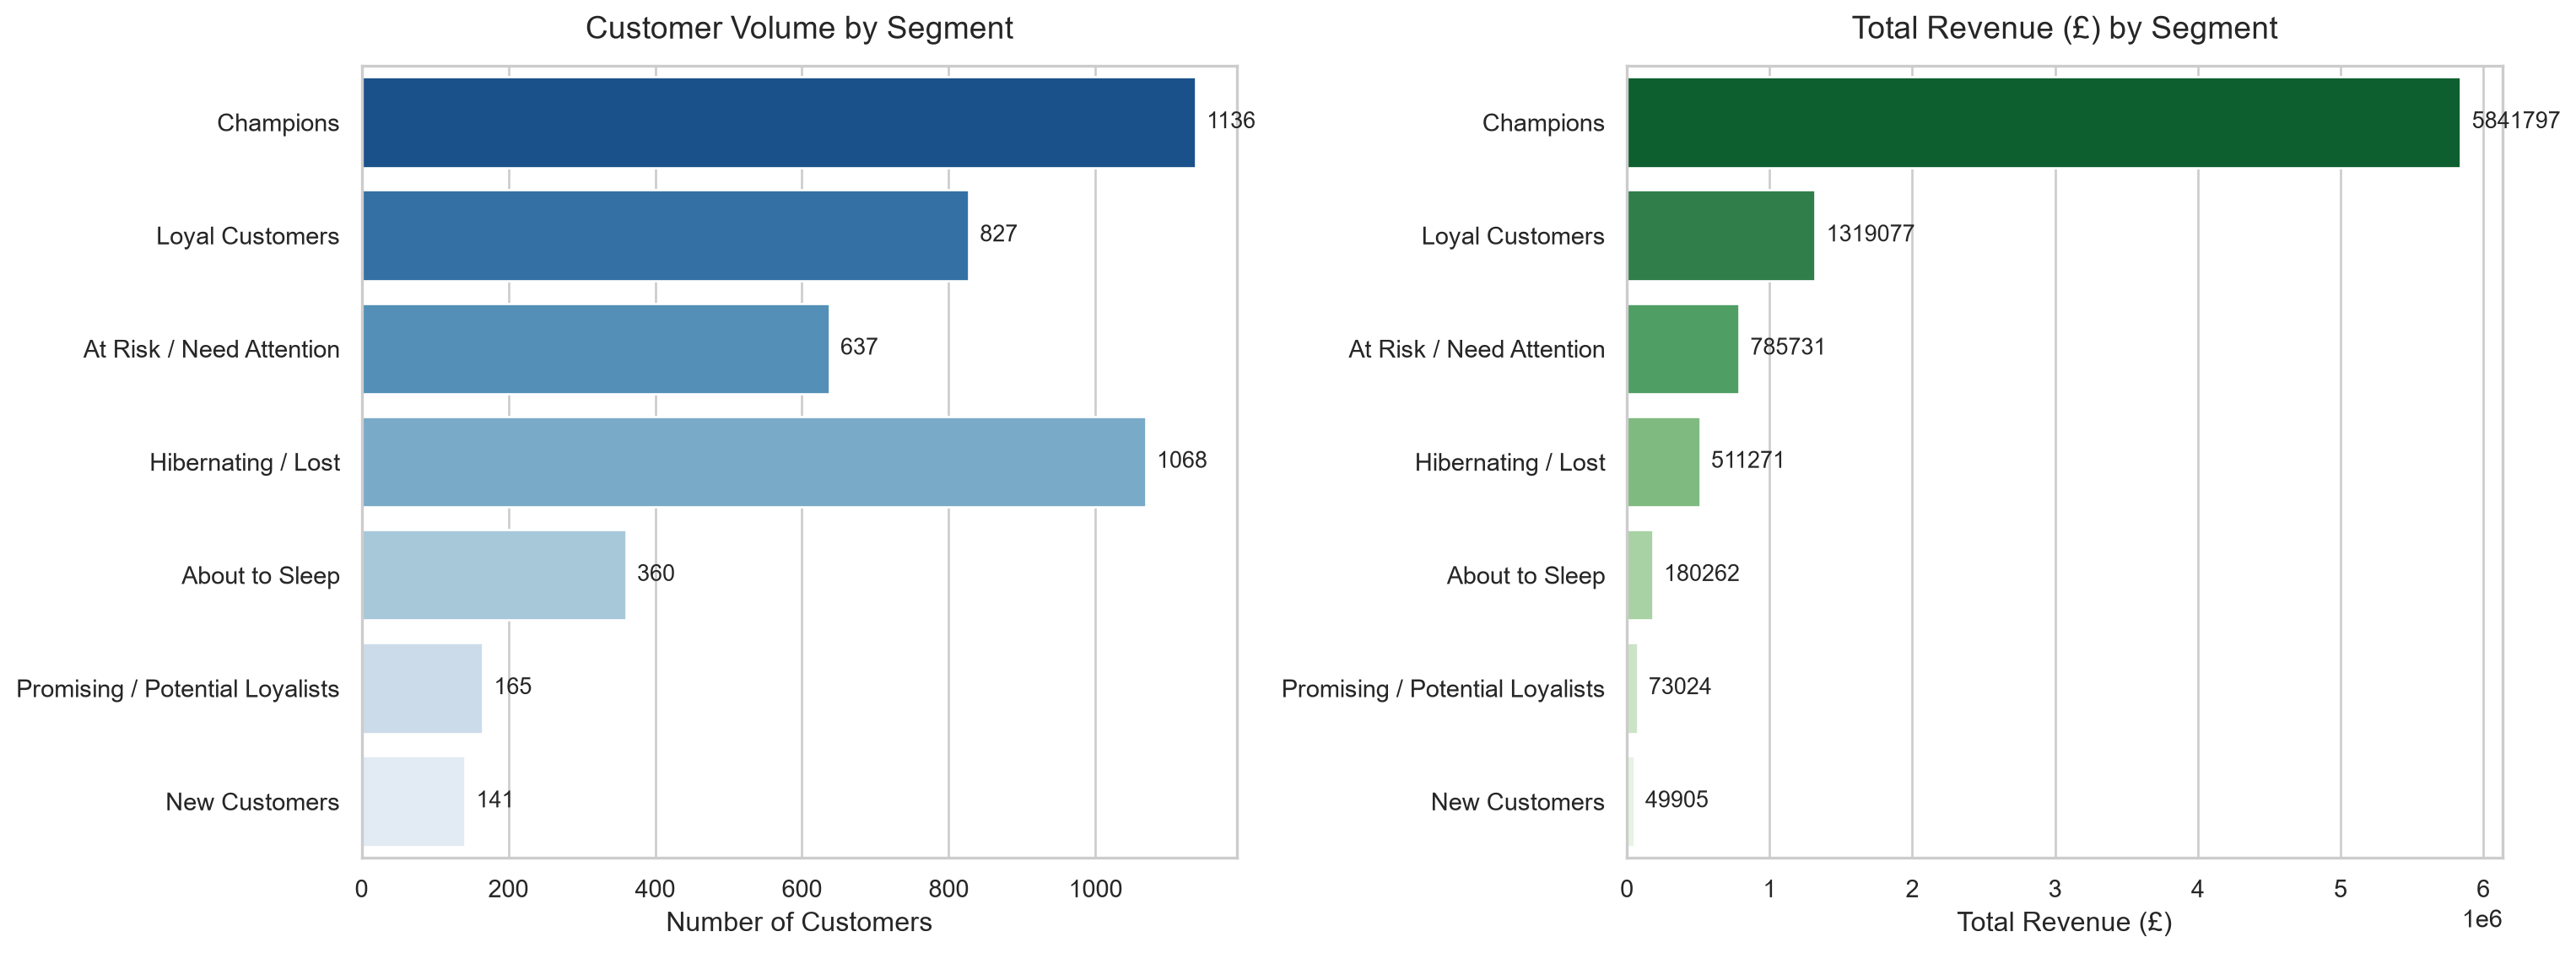

In [8]:
sns.set_theme(style="whitegrid")
plt.rcParams.update({"font.size": 10})

# 1. Aggregate segment metrics
segment_data = (
    rfm.groupby("Customer_Segment")
    .agg(
        Customer_Count=("CustomerID", "count"),
        Total_Revenue=("Monetary", "sum")
    )
    .reset_index()
    .sort_values(by="Total_Revenue", ascending=False)
)

# 2. Setup side-by-side subplot figures
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot A: Customer Count by Segment
sns.barplot(
    data=segment_data,
    x="Customer_Count",
    y="Customer_Segment",
    hue="Customer_Segment",
    legend=False,
    palette="Blues_r",
    ax=axes[0]
)
axes[0].set_title("Customer Volume by Segment", fontsize=14, pad=12)
axes[0].set_xlabel("Number of Customers")
axes[0].set_ylabel("")

# Subplot B: Total Revenue by Segment
sns.barplot(
    data=segment_data,
    x="Total_Revenue",
    y="Customer_Segment",
    hue="Customer_Segment",
    legend=False,
    palette="Greens_r",
    ax=axes[1]
)
axes[1].set_title("Total Revenue (£) by Segment", fontsize=14, pad=12)
axes[1].set_xlabel("Total Revenue (£)")
axes[1].set_ylabel("")

# Annotate values directly on bars for clear reading
for ax in axes:
    for container in ax.containers:
        ax.bar_label(container, fmt="%.0f", padding=5)

plt.tight_layout()
plt.show()